In [ ]:
import re
import os
import json
import pickle
import numpy as np
import pandas as pd
import nibabel as nib
from collections import defaultdict
import matplotlib.pyplot as plt


In [82]:
# load atlases
# read in atlases
atlas_base_path = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases"

# read in 2d mni mask
mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
og_shape = mask.shape
mask = mask.get_fdata().flatten()
brain_idx = np.where(mask>0)[0]

atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
atlas_vec = atlas.get_fdata().flatten()
atlas_only_brain = atlas_vec[brain_idx] # contains the schaefer parcel numbers
cortex_vx = np.where(atlas_only_brain != 0)[0]
parcel_nums = atlas_only_brain[cortex_vx]

# Making empty templates to save output
empty_schaefer = np.zeros(atlas_only_brain.shape)
empty_mni = np.zeros(atlas_vec.shape)

demo_data = pd.read_csv("/home/zachkaras/fmri/fmri_model/master-survey-data.csv")

def find_cutoff(vec, threshold = 10**4):
    
    # I can find the threshold point based on sorting, then keep everything in the same place
    copy = vec.copy()
    copy.sort()
    cutoff = copy[-threshold-1]
    return cutoff

def nested_dict():
    return defaultdict(nested_dict)

class Regression_Info(object):
    # [model_name, task, look_ahead, n_delays, layer, stat]
    def __init__(self, model_name=None, task=None, look_ahead=None, n_delays=None, layer=None, stat=None):
        self.model_name = model_name
        self.task       = task
        self.look_ahead = look_ahead
        self.n_delays   = n_delays
        self.layer      = layer
        self.stat       = stat
        
    def __str__(self):
        return f"model: {self.model_name}, task: {self.task}, look-ahead: {self.look_ahead}, n-delays: {self.n_delays}, layer: {self.layer}, stat: {self.stat}"

def parse_regression_info(path):
    
    parts = path.split('-') 
    # example: ['codegemma_7b', 'code', 'look_ahead_by_1', 'ndelays_0', 'layer_28', 'correlations.pkl']
    info = Regression_Info()
    info.model_name = parts[0]
    info.task       = parts[1]
    info.look_ahead = parts[2]
    info.n_delays   = parts[3]
    info.layer      = parts[4]
    info.stat       = (parts[5])[:-4]
    
    return info


In [84]:
# looking at specific combinations of parameters
# 4 delays, look ahead by 10
# 16 delays, look ahead by 0
# iterate through directories
base = "/storage1/fmri_model_data/ridge_regression_pca_params"
participants = os.listdir(base)
param1 = r'(?=.*ndelays_4)(?=.*look_ahead_by_10)'
param2 = r'(?=.*ndelays_16)(?=.*look_ahead_by_0)'
stat1 = 'correlations'
stat2 = 'cosine_similarities'

# keep track of stats
top_means = nested_dict()
top_stds  = nested_dict()

for p in participants:
    print(p)
    person_path = f"{base}/{p}"
    person_files = os.listdir(person_path)
    # (?=.*cat)(?=.*dog)
    person_files = [f for f in person_files if re.search(param1, f)]
    stat_files = [f for f in person_files if re.search(stat1, f)]
    # print(len(person_files), person_files)
    
    for pkl in stat_files:
        info = parse_regression_info(pkl)
        pickle_path = f"{person_path}/{pkl}"
        
        with open(pickle_path, 'rb') as f:
            corr_values = pickle.load(f)
        cutoff = find_cutoff(corr_values)
        # print(len(stat_vec))
        top_voxel_idx = (np.where(corr_values > cutoff))[0]
        top_voxel_vals = corr_values[top_voxel_idx]
        # corr_values.sort()
        # top_corrs = corr_values[-10**4:]
        top_mean = np.mean(top_voxel_vals)
        top_std  = np.std(top_voxel_vals)
        
        top_means[p][info.task][info.model_name][info.layer] = top_mean
        top_stds[p][info.task][info.model_name][info.layer] = top_std
    
    # break
    

111
121
150
112
101
130
203
125
204
117
134
201
122
151
108
133
129
105
118
109
144
119
141
138
142


In [85]:
participant_performance = defaultdict(list)

# RQ2 - how do the model layers (early vs. late) relate to correlation? For each model, collect correlation values at each layer
layer_performance = nested_dict()

# RQ3 - how do the different models relate to ridge regression performance? Collect correlation values for each model
model_performance = defaultdict(list)

# RQ4 - how do the tasks compare to one another? Collect correlation values for the two tasks
task_performance = defaultdict(list)

for person, taskModelLayerStat in top_means.items():
    for task, modelLayerStat in taskModelLayerStat.items():
        if task == 'prose':
            continue
        for model,layerStat in modelLayerStat.items():
            for layer,stat in layerStat.items():
                val = top_means[person][task][model][layer]
                # val = top_stds[person][task][model][layer]
                # val = corr_means[person][task][model][layer]
                # val = corr_stds[person][task][model][layer]
                
                participant_performance[person].append(val)    
                model_performance[model].append(val)
                task_performance[task].append(val)
                
                if layer not in layer_performance[model].keys():
                    layer_performance[model][layer] = [val]
                else:
                    layer_performance[model][layer].append(val)

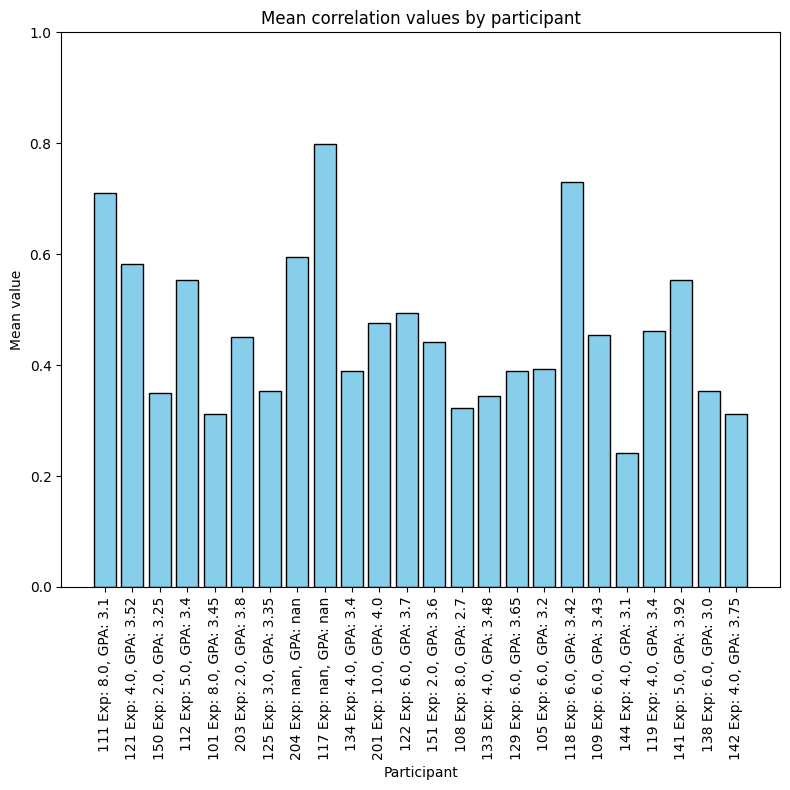

In [86]:
# by participant
def participant_index(id):
    # idx = (np.where(demo_data['id'] == int(id)))[0]
    # print(id, idx)
    return (np.where(demo_data['id'] == int(id)))[0][0]

# Compute means
labels = list(participant_performance.keys())
# Semesters experience and GPA
labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]

# code correct and code complete
# labels = [f"{l} Correct: {demo_data.loc[participant_index(l), 'code_correct']}, Complete: {demo_data.loc[participant_index(l), 'code_complete']}" for l in labels]

# code more structured, typing constraints, instinct vs solved
# labels = [f"{l} Structured: {demo_data.loc[participant_index(l), 'Code_more_structured']}, Typing Trouble: {demo_data.loc[participant_index(l), 'Typing Constraints']}, Solved {demo_data.loc[participant_index(l), 'Code_LR_Instinct_vs_Solved']}" for l in labels]

means = [np.mean(v) for v in participant_performance.values()]

# Plot
plt.figure(figsize=(8,8))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("Participant")
plt.xticks(rotation=90)
plt.ylim([0.0, 1])
plt.title("Mean correlation values by participant")
plt.tight_layout()
plt.show()

In [89]:
for model,layers in layer_performance.items():
    l = sorted(layers.keys(), key=lambda x: int(x.split('_')[1]))
    print(model, l)

        

deepseek_2b ['layer_0', 'layer_3', 'layer_6', 'layer_9', 'layer_12', 'layer_18', 'layer_21', 'layer_24']
codegemma_2b ['layer_0', 'layer_4', 'layer_6', 'layer_10', 'layer_12', 'layer_14', 'layer_16', 'layer_18']
deepseek_6b ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_24', 'layer_28', 'layer_32']
starcoder2_3b ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28']
codegemma_7b ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_24', 'layer_28']
starcoder2_7b ['layer_0', 'layer_4', 'layer_8', 'layer_12', 'layer_16', 'layer_20', 'layer_28', 'layer_32']


In [88]:
del layer_performance['deepseek_2b']['layer_15']
del layer_performance['codegemma_2b']['layer_2']
del layer_performance['codegemma_2b']['layer_8']
del layer_performance['deepseek_6b']['layer_20']
del layer_performance['starcoder2_7b']['layer_24']

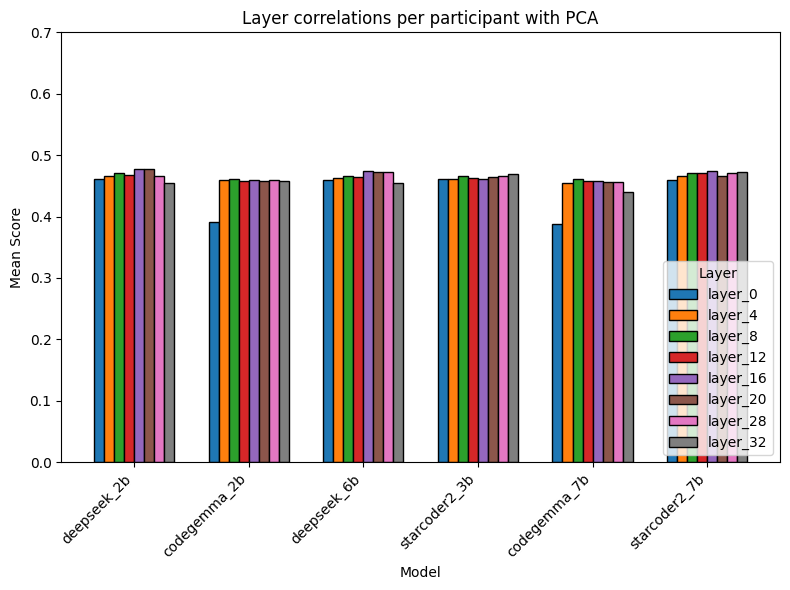

In [90]:
# layer bar chart
layer_performance = json.loads(json.dumps(layer_performance))

models = list(layer_performance.keys())
layers = list(next(iter(layer_performance.values())).keys())  # assume all participants have same tasks

layers = sorted(
    next(iter(layer_performance.values())).keys(),
    key=lambda x: int(x.split('_')[1])
)

# Compute means
# means = {p: [np.mean(data[p][t]) for t in tasks] for p in participants}
means = {}
for model, layerScores in layer_performance.items():
    layers = sorted(layerScores.keys(), key=lambda x: int(x.split('_')[1]))
    for layer in layers:
    # for layer,scores in layerScores.items():
        # print(model, layer)
        scores = layer_performance[model][layer]
        # print(np.mean(scores), scores)
        if model not in means.keys():
            means[model] = [np.mean(scores)]
        else:
            # print(model, layer, scores)
            means[model].append(np.mean(scores))
    #     break
    # break
            
# means = {m: [layer_performance[m][l] for l in layers] for m in models}
# print(layers)
# print([means[m][0] for m in models])
# Plot grouped bars
x = np.arange(len(models))  # positions for participants
width = 0.35 / len(layers) * 2     # adjust width depending on number of tasks

plt.figure(figsize=(8,6))
for i, layer in enumerate(layers):
    plt.bar(x + i*width, [means[m][i] for m in models],
            width, label=layer, edgecolor='black')

plt.xlabel("Model")
plt.ylim([0.0,0.7])
plt.ylabel("Mean Score")
plt.title("Layer correlations per participant with PCA")
plt.xticks(x + width*(len(layers)-1)/2, models, rotation=45, ha='right')
plt.legend(title="Layer", loc='lower right')
plt.tight_layout()
plt.show()

In [73]:
means

{'deepseek_2b': [np.float64(0.46034307042877404),
  np.float64(0.46639505400121123),
  np.float64(0.47036582697823204),
  np.float64(0.4673176222846636),
  np.float64(0.47729274500476476),
  np.float64(0.47803297073212964),
  np.float64(0.4661721310050331),
  np.float64(0.4544001291311021)],
 'codegemma_2b': [np.float64(0.3917905826791845),
  np.float64(0.4596714631352509),
  np.float64(0.4614974583747517),
  np.float64(0.45778108284494373),
  np.float64(0.45883661274648285),
  np.float64(0.4580330303369939),
  np.float64(0.4600358829779903),
  np.float64(0.45715258982494045)],
 'deepseek_6b': [np.float64(0.45913057001621027),
  np.float64(0.4625293459517525),
  np.float64(0.46633035945536916),
  np.float64(0.4647870320607424),
  np.float64(0.47416363158083463),
  np.float64(0.4726321243335711),
  np.float64(0.4728808453888314),
  np.float64(0.45516979183238343)],
 'starcoder2_3b': [np.float64(0.4615926032799201),
  np.float64(0.46066654005556157),
  np.float64(0.4666661486137344),
  n

In [ ]:
# brain plots